# Sentiment Analysis using SimpleRNN

## Import Modules

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, SimpleRNN, Dense
from tensorflow.keras.utils import plot_model, pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.text import Tokenizer

# import train test split from sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import pandas as pd

## Prepare Synthetic Data

In [2]:
sentences = [
    "I hate this thing",
    "This is terrible",
    "Really bad experience",
    "So disappointed today",
    "Not good at all",
    "I love this movie",
    "This is amazing",
    "Great job well done",
    "What a pleasant day",
    "Happy with the result"
]

sentiments = ["negative", "negative", "negative", "negative", "negative",
              "positive", "positive", "positive", "positive", "positive"]

In [3]:
df = pd.DataFrame(data={"sentences": sentences, "sentiments": sentiments})
df

,sentences,sentiments
0,I hate this thing,negative
1,This is terrible,negative
2,Really bad experience,negative
3,So disappointed today,negative
4,Not good at all,negative
5,I love this movie,positive
6,This is amazing,positive
7,Great job well done,positive
8,What a pleasant day,positive
9,Happy with the result,positive


## Tokenization

In [4]:
# oov mean out of vaocabulary token.
# If a token is found which is not in vocabulary, replace with <na>
t = Tokenizer(oov_token='<na>')

t.fit_on_texts(df['sentences'])

In [5]:
print(
    t.document_count, '\n', 
    t.num_words, '\n', 
    t.word_index, '\n',
    t.word_counts, "\n"
)

10 
 None 
 {'<na>': 1, 'this': 2, 'i': 3, 'is': 4, 'hate': 5, 'thing': 6, 'terrible': 7, 'really': 8, 'bad': 9, 'experience': 10, 'so': 11, 'disappointed': 12, 'today': 13, 'not': 14, 'good': 15, 'at': 16, 'all': 17, 'love': 18, 'movie': 19, 'amazing': 20, 'great': 21, 'job': 22, 'well': 23, 'done': 24, 'what': 25, 'a': 26, 'pleasant': 27, 'day': 28, 'happy': 29, 'with': 30, 'the': 31, 'result': 32} 
 OrderedDict([('i', 2), ('hate', 1), ('this', 4), ('thing', 1), ('is', 2), ('terrible', 1), ('really', 1), ('bad', 1), ('experience', 1), ('so', 1), ('disappointed', 1), ('today', 1), ('not', 1), ('good', 1), ('at', 1), ('all', 1), ('love', 1), ('movie', 1), ('amazing', 1), ('great', 1), ('job', 1), ('well', 1), ('done', 1), ('what', 1), ('a', 1), ('pleasant', 1), ('day', 1), ('happy', 1), ('with', 1), ('the', 1), ('result', 1)]) 



## Generate Numeric Sequence from Tokens

In [7]:
# Numerical encode the docs, replace word with it's index
sequences = t.texts_to_sequences(df['sentences'])
sequences

[[3, 5, 2, 6],
 [2, 4, 7],
 [8, 9, 10],
 [11, 12, 13],
 [14, 15, 16, 17],
 [3, 18, 2, 19],
 [2, 4, 20],
 [21, 22, 23, 24],
 [25, 26, 27, 28],
 [29, 30, 31, 32]]

## Make all sentences equal size using Paddings

In [8]:
max_len = 4
X = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')

In [ ]:
lbl_enc = LabelEncoder()
y = lbl_enc.fit_transform(df["sentiments"]).astype('float32').reshape(-1, 1)

y

## Train Test Split our Small Data

In [23]:
X_train, X_test, y_train, y_test, s_train, s_test = train_test_split(
    X, y, df['sentences'].to_numpy(), test_size=0.2, random_state=42, stratify=y
)

X_train, y_train, s_train

(array([[25, 26, 27, 28],
        [14, 15, 16, 17],
        [ 2,  4,  7,  0],
        [ 3,  5,  2,  6],
        [ 2,  4, 20,  0],
        [ 3, 18,  2, 19],
        [21, 22, 23, 24],
        [ 8,  9, 10,  0]]),
 array([[1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [0.]], dtype=float32),
 array(['What a pleasant day', 'Not good at all', 'This is terrible',
        'I hate this thing', 'This is amazing', 'I love this movie',
        'Great job well done', 'Really bad experience'], dtype=object))

In [24]:
X_test, y_test, s_test

(array([[11, 12, 13,  0],
        [29, 30, 31, 32]]),
 array([[0.],
        [1.]], dtype=float32),
 array(['So disappointed today', 'Happy with the result'], dtype=object))

## Build the RNN Model

In [11]:
model = Sequential()
# Timestamp 4, input shape 1. Model will rollout 4 times processing 1 word at a time
model.add(Input(shape=(max_len,1))) 
# Add a simple RNN with 3 units, we don't see the outputs for each timestamp
model.add(SimpleRNN(32, activation='tanh', return_sequences=False)) 
model.add(Dense(1, activation="sigmoid"))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

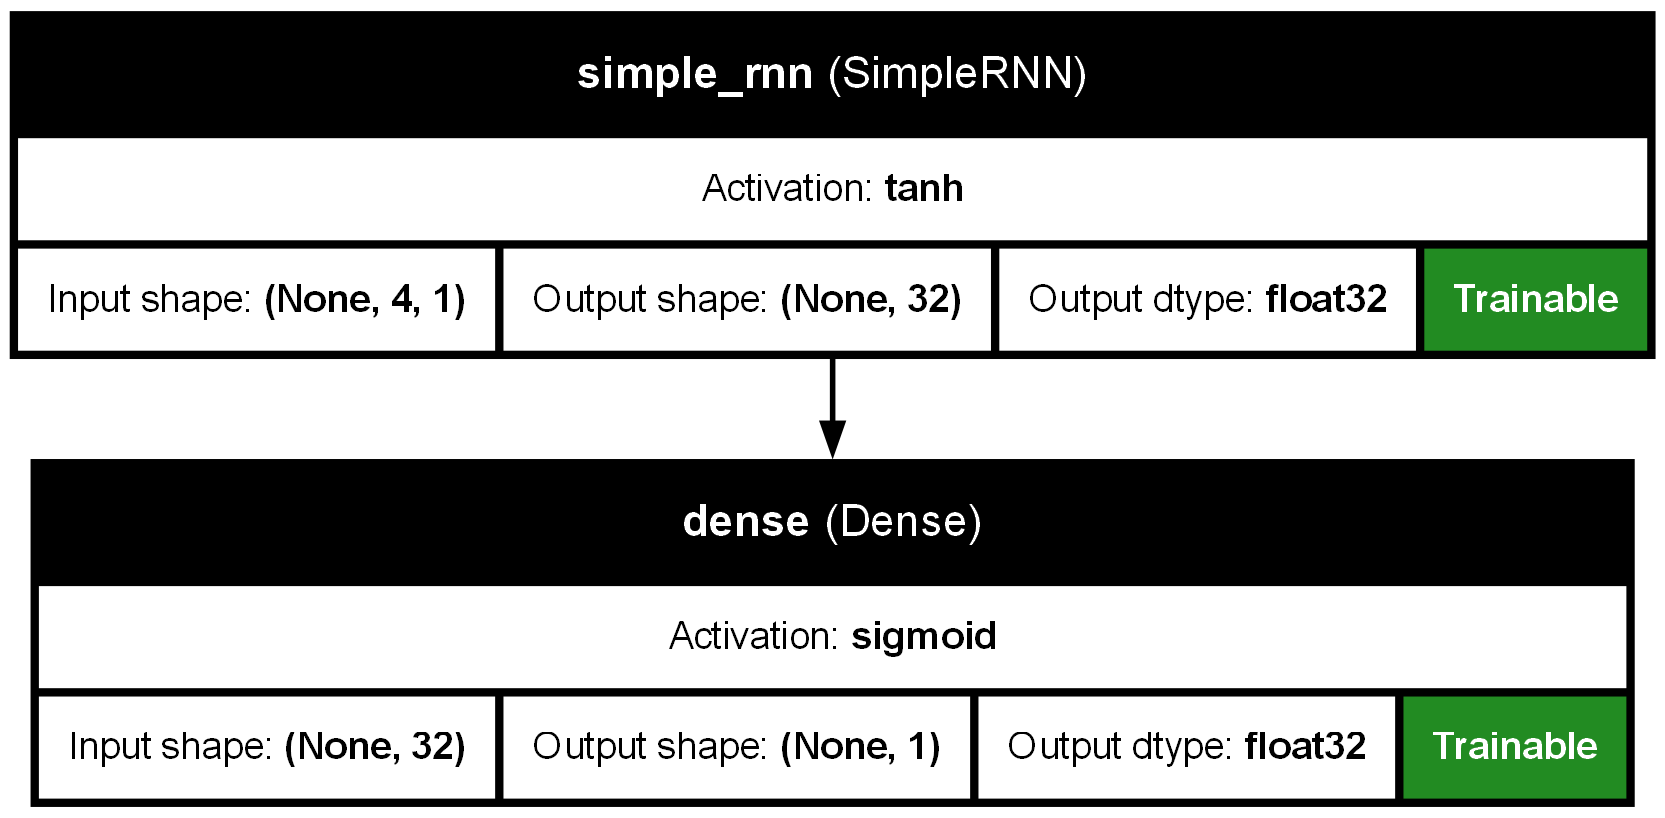

In [12]:
plot_model(
    model, 
    show_shapes=True,
    show_dtype=True,
    show_layer_activations=True,
    show_layer_names=True,
    show_trainable=True
)

## Compile and Train the Model

In [13]:
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

In [14]:
es = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1)

In [15]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    validation_data=(X_test, y_test),
    batch_size=1,
    callbacks=[es],
    verbose=1
)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.5000 - loss: 0.7029 - val_accuracy: 1.0000 - val_loss: 0.6050
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6250 - loss: 0.6681 - val_accuracy: 1.0000 - val_loss: 0.5382
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6250 - loss: 0.6418 - val_accuracy: 1.0000 - val_loss: 0.4968
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7500 - loss: 0.6302 - val_accuracy: 1.0000 - val_loss: 0.5010
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7500 - loss: 0.6093 - val_accuracy: 1.0000 - val_loss: 0.4741
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7500 - loss: 0.6006 - val_accuracy: 1.0000 - val_loss: 0.4401
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7500 - loss: 0.5858 - val_accuracy: 1.0000 - val_loss: 0.4108
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7500 - loss: 0.5804 - val_accuracy: 1.0000 - val_loss: 0.4174
Epoch

## Make Predictions

In [16]:
predictions = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step


In [25]:
for i, pred in enumerate(predictions):
    res = 'Positive' if pred > 0.5 else 'Negative'  
    print(f"Sentenece: {s_test[i]} -> Sentiment: {res}")

Sentenece: So disappointed today -> Sentiment: Negative
Sentenece: Happy with the result -> Sentiment: Positive
